# Projet- Prévision des clics publicitaires

## Description des données

Les données fournies contiennent les enregistrements quotidiens des publicités de **185 clients** de la plateforme **Adbot**. Chaque enregistrement contient des informations relatives aux publicités :
- **Coût** de la publicité
- **Nombre d'impressions** (affichages)
- **Nombre de clics** (target variable)
- **Type de publicité** (EXPANDED_TEXT_AD, RESPONSIVE_SEARCH_AD, EXPANDED_DYNAMIC_SEARCH_AD)
- **Devise** utilisée (ZAR, USD)
- **Nombre de mots-clés** utilisés dans les publicités

Les données contiennent également les **appels reçus** par les clients à la suite de l'hébergement de publicités :
- Nombre quotidien d'appels reçus/manqués
- Durée de chaque appel

### Objectif
Prédire le nombre de **clics** qu'une publicité recevra dans **1 à 2 semaines** pour chaque client. Les modèles doivent être à la fois **précis** et **interprétables** (identification des variables d'impact maximum).

## Approche et méthodologie

1. **Nettoyage et prétraitement** : suppression des colonnes trop manquantes, conversion de la date en format datetime, création de séries temporelles complètes par client
2. **Exploration des données** : visualisation de l'évolution des clics, impressions et coûts dans le temps ; analyse par devise et type de publicité ; détection de tendances et saisonnalité
3. **Feature Engineering** : création de features temporelles (jour, mois, jour de semaine, jours fériés), encodage des variables catégorielles, calcul de lags et différences, statistiques par semaine/mois
4. **Modélisation** : comparaison de plusieurs algorithmes (LightGBM, XGBoost, RandomForest) avec validation temporelle
5. **Évaluation** : calcul du RMSE ; analyse des importances de features pour l'interprétabilité

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import kruskal, pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder

### 1. Importation et nettoyage des données

In [102]:
# Importation des données
df = pd.read_csv("../data/Train_clicks.csv")
df.info()
df.head()

# Plage de dates et nombre de jours
print(f"\nPlage de dates: {df['date'].min()} à {df['date'].max()}")
print(f"Nombre de jours couverts: {(pd.to_datetime(df['date']).max() - pd.to_datetime(df['date']).min()).days + 1}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289926 entries, 0 to 289925
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   impressions         289526 non-null  float64
 1   clicks              289526 non-null  float64
 2   cost                289526 non-null  float64
 3   conversions         289526 non-null  float64
 4   ad_type             289526 non-null  object 
 5   currency            289526 non-null  object 
 6   ID                  289926 non-null  object 
 7   date                289926 non-null  object 
 8   call_type           36900 non-null   object 
 9   call_status         36900 non-null   object 
 10  start_time          36900 non-null   object 
 11  duration            36900 non-null   float64
 12  end_time            36900 non-null   object 
 13  display_location    36900 non-null   object 
 14  impression_share    289926 non-null  float64
 15  conversions_calls   280071 non-nul

In [103]:
# Étape 1 : On supprime les observations sans target (clics manquants) car elles ne peuvent pas servir à l'entraînement
df_train = df[~df["clicks"].isna()].copy()
df_train.reset_index(drop=True, inplace=True)

# Étape 2 : On convertit la colonne 'date' en format datetime pour faciliter les opérations temporelles
df_train['date'] = pd.to_datetime(df_train['date'])

# Étape 3 : On supprime les colonnes avec trop de valeurs manquantes (données d'appels peu pertinentes pour prédire les clics)
df_train.drop(['call_type', 'call_status', 'start_time', 'duration', 'end_time', 'display_location', 'conversions_calls',
                'conversions'], axis=1, inplace=True)

# Étape 4 : On détecte les doublons
''' 2 types de doublons : 
- Doublons partiels (même ID et date) - NORMAL : plusieurs annonces par client le même jour
- Doublons complets (ligne entièrement dupliquée) - À SUPPRIMER 
'''
doublons_id_date = df_train.duplicated(subset=['ID', 'date']).sum()
print(f"\nDoublons partiels (ID, date): {doublons_id_date}")

doublons_complets = df_train.duplicated(keep=False).sum()
print(f"\nDoublons complets: {doublons_complets}")

# On supprime les doublons complets
if doublons_complets > 0:
    df_train = df_train.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"Nouvelles dimensions: {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")


Doublons partiels (ID, date): 221958

Doublons complets: 23787
Nouvelles dimensions: 274139 lignes, 11 colonnes


In [104]:
display(df_train.shape)  
display(df_train.tail()) 
df_train.head() 

(274139, 11)

,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
274134,299.0,29.0,6809.716151,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,5.0,13.0
274135,410.0,28.0,6598.474957,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,16.0
274136,281.0,11.0,3642.348176,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,14.0
274137,41.0,5.0,547.477180,EXPANDED_DYNAMIC_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,0.0,0.0,0.0
274138,77.0,1.0,394.983536,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,13.0


,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
0,142.0,15.0,3393.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,5.0,11.0
1,89.0,8.0,1817.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0
2,59.0,8.0,1743.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,10.0
3,78.0,4.0,917.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,3.0,13.0
4,20.0,1.0,217.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0


## 2. Analyse Exploratoire (EDA)

Cette section explore en profondeur la structure et les caractéristiques des données :
- Statistiques descriptives complètes (min, max, mean, std, quartiles)
- Analyse des valeurs manquantes dans chaque colonne (heatmap)
- Vérification de la couverture temporelle et du nombre de clients uniques
- Distribution des observations par client (certains clients ont-ils peu de données ?)
- Détection des outliers dans les variables clés (clics, impressions, coûts)
- Distributions univariées (histogrammes et boxplots)

In [105]:
# Liste les colonnes restantes après le nettoyage
df_train.columns

Index(['impressions', 'clicks', 'cost', 'ad_type', 'currency', 'ID', 'date',
       'impression_share', 'headline1_len', 'headline2_len',
       'ad_description_len'],
      dtype='object')

### 2.1 Statistiques descriptives et couverture des données

Visualisation complète des statistiques (min, max, mean, std, quartiles) pour chaque variable numérique et analyse de la distribution des observations par client.

In [106]:
# Statistiques descriptives complètes
display(df_train.describe().T)

,count,mean,min,25%,50%,75%,max,std
impressions,274139.0,67.840464,0.0,6.0,22.0,67.0,6833.0,144.467585
clicks,274139.0,7.596716,0.0,0.0,2.0,6.0,4227.0,36.739508
cost,274139.0,2069.547506,0.0,0.0,533.662476,1963.474748,719928.0,6873.5168
date,274139,2022-10-08 03:52:47.010896128,2020-01-01 00:00:00,2022-02-01 00:00:00,2022-11-17 00:00:00,2023-07-24 00:00:00,2024-02-13 00:00:00,NaN
impression_share,274139.0,16.580755,5.0,9.99,11.390134,19.937292,100.0,12.105516
headline1_len,274139.0,2.738622,0.0,2.0,3.0,4.0,7.0,1.565955
headline2_len,274139.0,2.888002,0.0,2.0,3.0,4.0,7.0,1.658795
ad_description_len,274139.0,10.692247,0.0,10.0,12.0,14.0,20.0,4.501895


Nombre de clients uniques: 185

Observations par client (statistiques):
  Min: 49
  Max: 14759
  Mean: 1481.83
  Median: 439.00


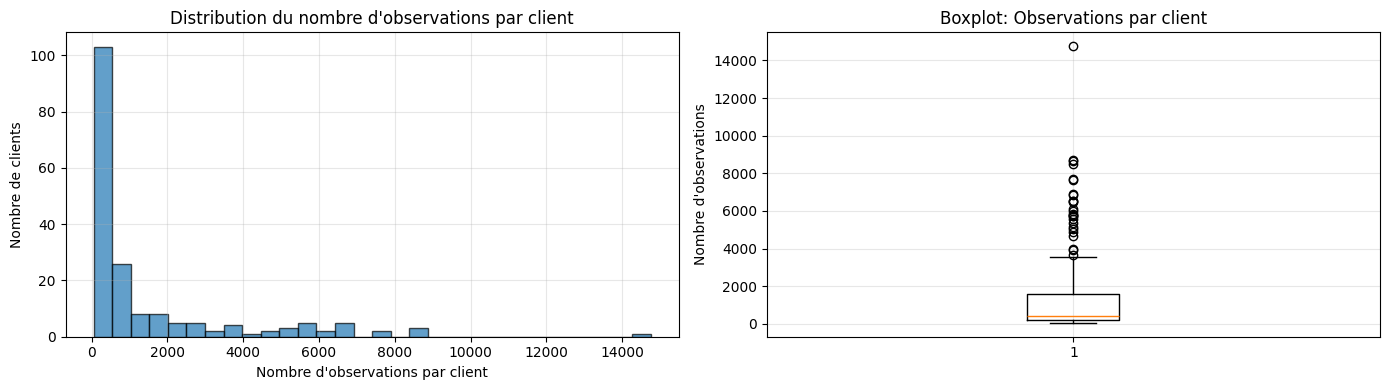

In [107]:
# On analyse des clients uniques et couverture temporelle
n_clients = df_train['ID'].nunique()
print(f"Nombre de clients uniques: {n_clients}")

# On distribue des observations par client
obs_per_client = df_train.groupby('ID').size()
print(f"\nObservations par client (statistiques):")
print(f"  Min: {obs_per_client.min()}")
print(f"  Max: {obs_per_client.max()}")
print(f"  Mean: {obs_per_client.mean():.2f}")
print(f"  Median: {obs_per_client.median():.2f}")

# Graphe de distribution par client
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(obs_per_client, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Nombre d'observations par client")
plt.ylabel("Nombre de clients")
plt.title("Distribution du nombre d'observations par client")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(obs_per_client)
plt.ylabel("Nombre d'observations")
plt.title("Boxplot: Observations par client")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Détection des outliers

Identification des valeurs aberrantes (outliers) dans les variables clés en utilisant la méthode IQR (InterQuartile Range) avec visualisation en boxplots.


clicks:
  Outliers (IQR): 25711 (9.38%)
  Limites: [-9.00, 15.00]

impressions:
  Outliers (IQR): 29809 (10.87%)
  Limites: [-85.50, 158.50]

cost:
  Outliers (IQR): 26493 (9.66%)
  Limites: [-2945.21, 4908.69]


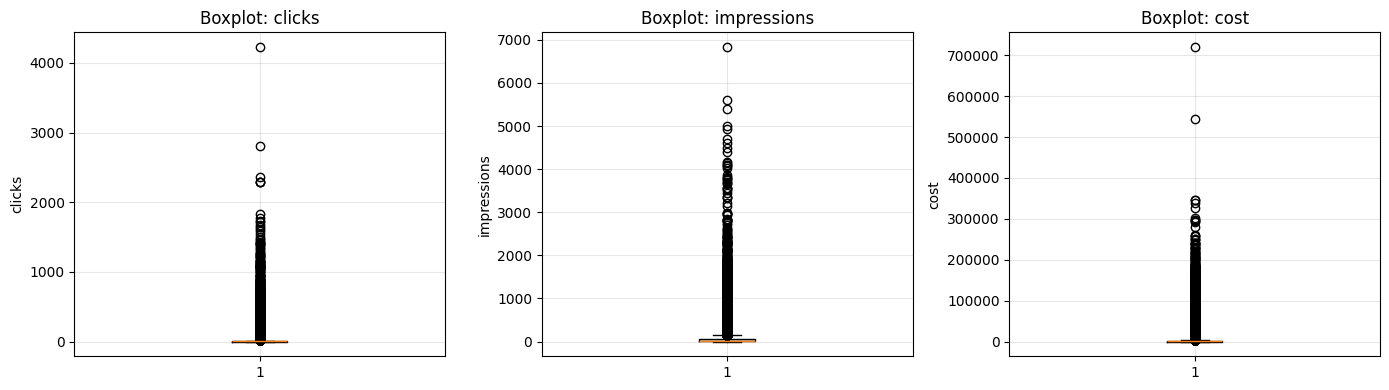

In [108]:
# Détection des outliers (clics, impressions, coûts)

numeric_cols = ['clicks', 'impressions', 'cost']
outliers_info = {}

for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df_train[col] < lower_bound) | (df_train[col] > upper_bound)).sum()
    outliers_info[col] = {
        'n_outliers': n_outliers,
        'pct_outliers': (n_outliers / len(df_train) * 100),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    
    print(f"\n{col}:")
    print(f"  Outliers (IQR): {n_outliers} ({outliers_info[col]['pct_outliers']:.2f}%)")
    print(f"  Limites: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Boxplots pour visualiser les outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_train[col].dropna())
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Distributions univariées

Analyse des distributions des variables numériques et catégorielles avec histogrammes et diagrammes en barres.

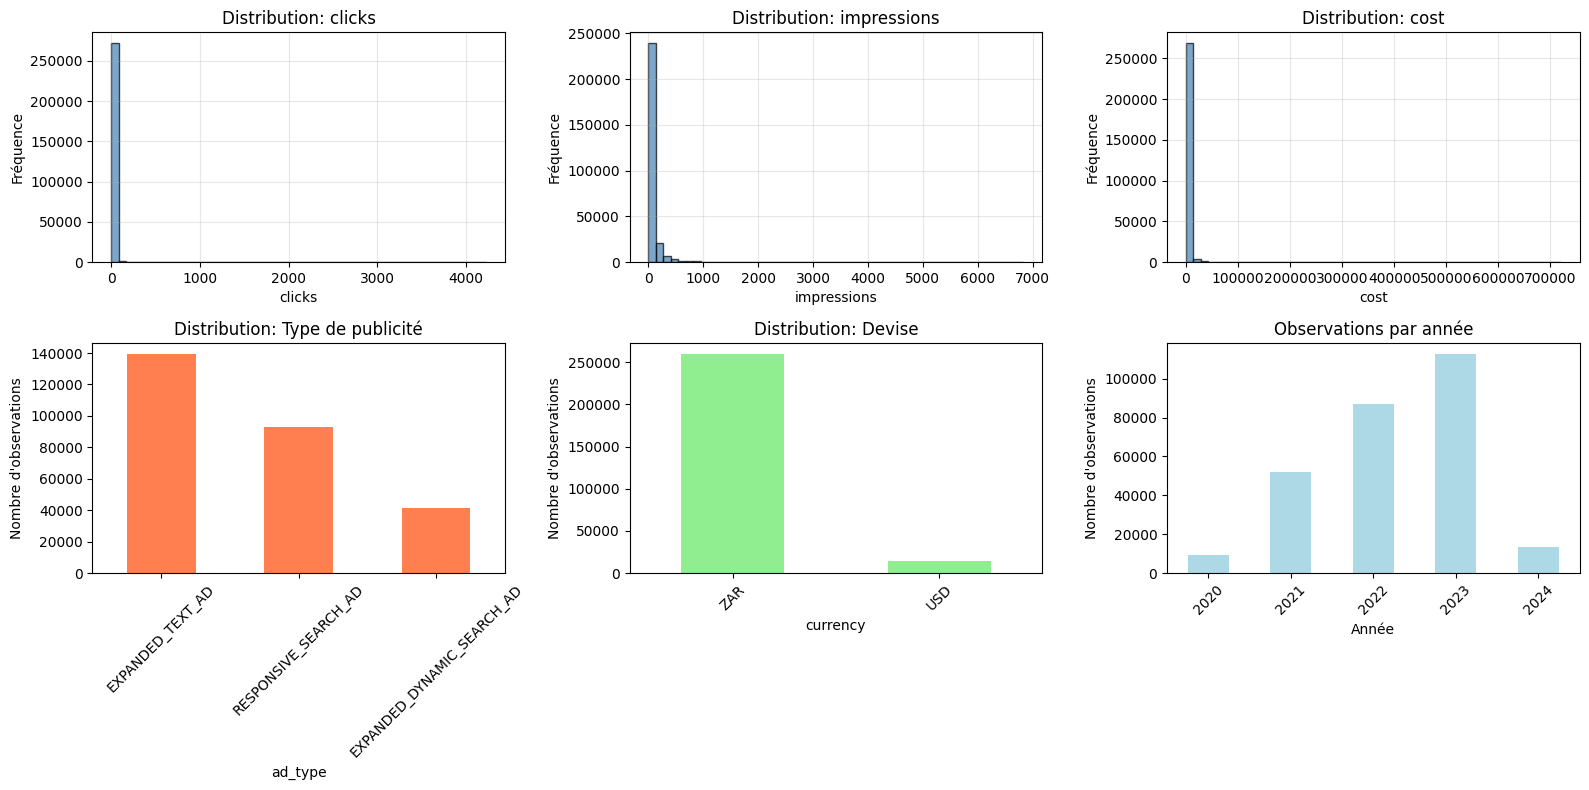

In [109]:
# Distributions univariées (histogrammes)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Histogrammes des variables numériques
for i, col in enumerate(numeric_cols):
    ax = axes[0, i]
    ax.hist(df_train[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.set_title(f"Distribution: {col}")
    ax.grid(True, alpha=0.3)

# Distributions des variables catégorielles
ax = axes[1, 0]
df_train['ad_type'].value_counts().plot(kind='bar', ax=ax, color='coral')
ax.set_title("Distribution: Type de publicité")
ax.set_ylabel("Nombre d'observations")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1, 1]
df_train['currency'].value_counts().plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title("Distribution: Devise")
ax.set_ylabel("Nombre d'observations")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Observations par année (si elle existe après nettoyage)
try:
    df_train['year_temp'] = pd.to_datetime(df_train['date']).dt.year
    ax = axes[1, 2]
    df_train['year_temp'].value_counts().sort_index().plot(kind='bar', ax=ax, color='lightblue')
    ax.set_title("Observations par année")
    ax.set_ylabel("Nombre d'observations")
    ax.set_xlabel("Année")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
except:
    pass

plt.tight_layout()
plt.show()

### 2.4 Analyse temporelle globale

Étude de l'évolution des clics, impressions et coûts dans le temps (2020-2024) et impact des variables catégorielles (devise, type de publicité) sur les clics.

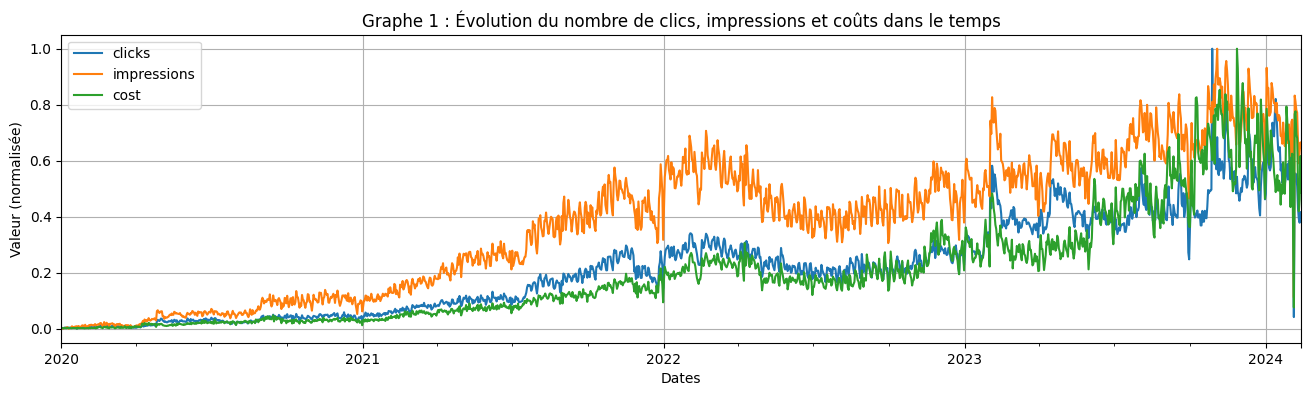

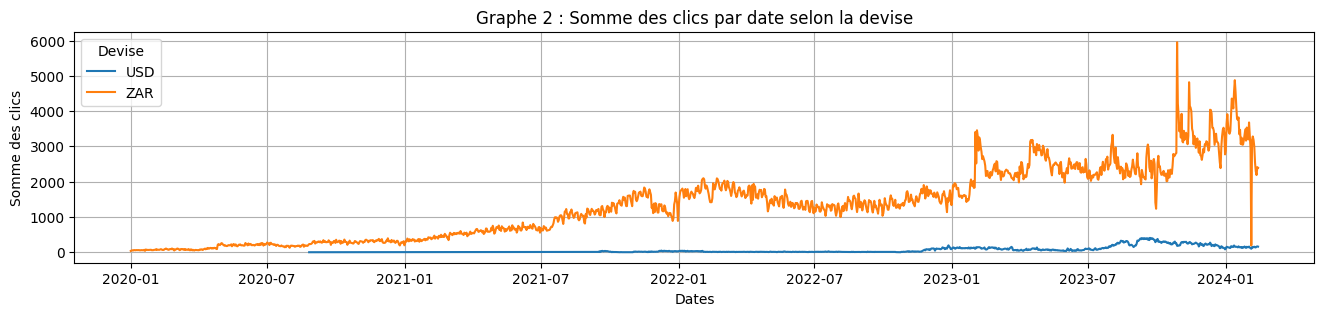

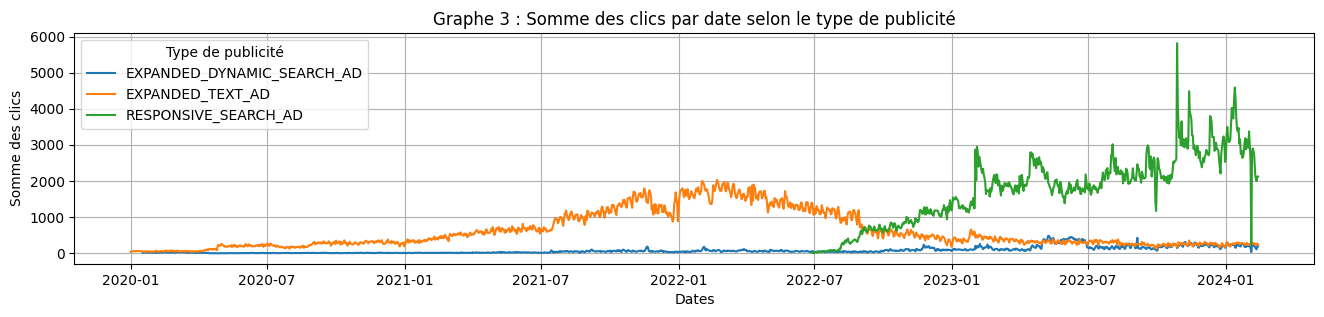

In [110]:
# Graphe 1 : Évolution globale (2020-2024)
# Normalisation min-max pour comparer trois variables à des échelles différentes
df_sum_clicks = df_train.groupby(['date'])[['clicks', 'impressions', 'cost']].sum().reset_index()
cols = ['clicks', 'impressions', 'cost']
df_sum_clicks[cols] = (df_sum_clicks[cols] - df_sum_clicks[cols].min()) / (df_sum_clicks[cols].max() - df_sum_clicks[cols].min())
df_sum_clicks.plot(x='date', y=cols, figsize=(16, 4))
plt.xlabel('Dates')
plt.ylabel('Valeur (normalisée)')
plt.title('Graphe 1 : Évolution du nombre de clics, impressions et coûts dans le temps')
plt.legend()
plt.grid(True)
plt.show()

# Graphe 2 : Impact de la devise
# Analyse des clics par devise pour voir si ZAR ou USD est dominant
df_sum_clicks_currency = df_train.groupby(['currency', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16, 3))
sns.lineplot(data=df_sum_clicks_currency, x='date', y='clicks', hue='currency')
plt.xlabel("Dates")
plt.ylabel('Somme des clics')
plt.title('Graphe 2 : Somme des clics par date selon la devise')
plt.legend(title='Devise')
plt.grid(True)
plt.show()

# Graphe 3 : Impact du type de publicité
# Analyse de la tendance pour chaque type de publicité (changement de stratégie marketing)
df_sum_clicks_par_ad = df_train.groupby(['ad_type', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16, 3))
sns.lineplot(data=df_sum_clicks_par_ad, x='date', y='clicks', hue='ad_type')
plt.xlabel("Dates")
plt.ylabel('Somme des clics')
plt.title('Graphe 3 : Somme des clics par date selon le type de publicité')
plt.legend(title='Type de publicité')
plt.grid(True)
plt.show()

**Interprétation des graphiques d'évolution temporelle:**

1. **Graphique 1**
 - On note une tendance globale fortement croissante des trois (03) métriques entre 2020 et 2024. Avec la digitalisation croissante, de plus en plus d'entreprises déplacent leurs efforts marketing vers le numérique, d'où l'augmentation des investissements publicitaires en ligne et ainsi la hausse du nombres de clics.
 - On remarque aussi qu'il y'a 3 phases dans la série des clics : 
   * *2020 - mi 2021* : niveau faible mais en croissance progressive
   * *fin 2021 - début 2022* : forte hausse et grande volatilité (pics très marqués allant jusqu'en 7000 clics)
   * *mi 2022 - 2024* : Stabilisation toujours avec tendance croissante, mais avec des fluctuations plus modérées

2. **Graphique 2**
 - La quasi-totalité des clics provient de la monnaie ZAR.
 - La courbe USD est très basse sur toute la période, avec une légère hausse fin 2023.
 - Les pics observés dans le graphe 1 sont presque exclusivement dus à ZAR.

3. **Graphique 3**
 - *EXPANDED_TEXT_AD* :
   * dominant jusqu’à mi-2022
   * chute progressive ensuite

 - *RESPONSIVE_SEARCH_AD* :
   * apparaît vers mi-2022
   * croissance rapide et devient le format dominant en 2023–2024
  Il semblerait qu'il y' ait un changement structurel de stratégie publicitaire avec l'abandon progressive des EXPANDED_TEXT_AD et l'adoption massive des RESPONSIVE_SEARCH_AD. Le type de publicité influence donc le niveau des clics.

 - *EXPANDED_DYNAMIC_SEARCH_AD* :
   * contribution très faible sur toute la période

### 2.6 Analyse de saisonnalité

Examen de l'évolution journalière des clics par année et par mois pour identifier les patterns saisonniers et variations cycliques.

- Analyse les clics de TOUS les clients combinés (agrégés)
- Vue macroscopique globale de la plateforme

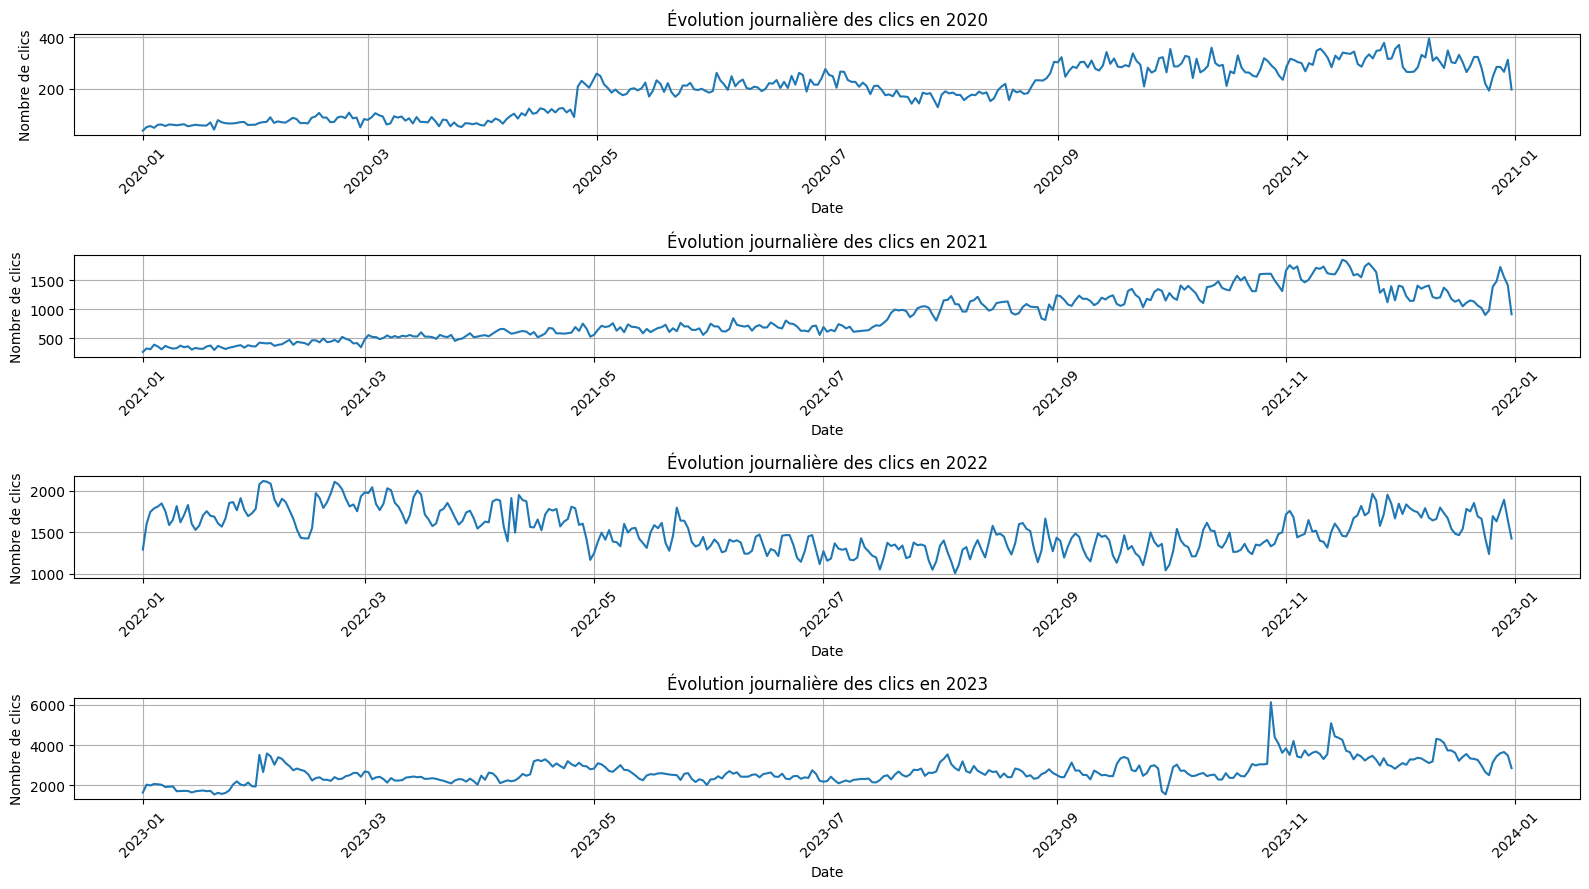

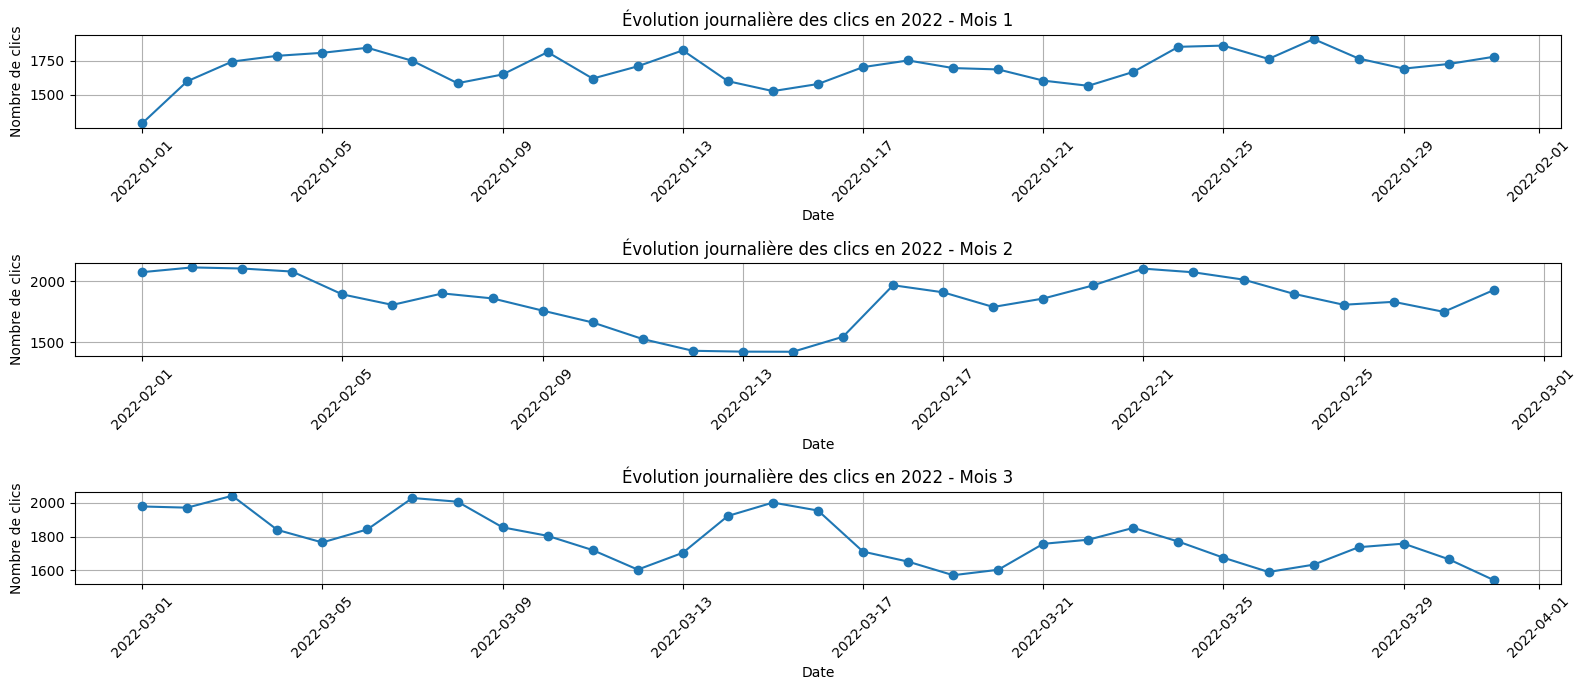

In [111]:
# Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9)) 

for i, annee in enumerate(annees, 1):
    df_year = df_train[df_train['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train[(df_train['date'].dt.year == annee_zoom) & (df_train['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Interprétation des graphiques de l'évolution journalières des clics:**

Il n'y a pas de saisonnalité apparente. Cependant ici on considère la somme des clics tout clients confondus. Il serait judicieux d'analyser la série pour chaque client pris individuellement.

- Analyse les clics d'UN SEUL client (le premier de la liste : liste_id[0])
- Vue microscopique d'un client spécifique

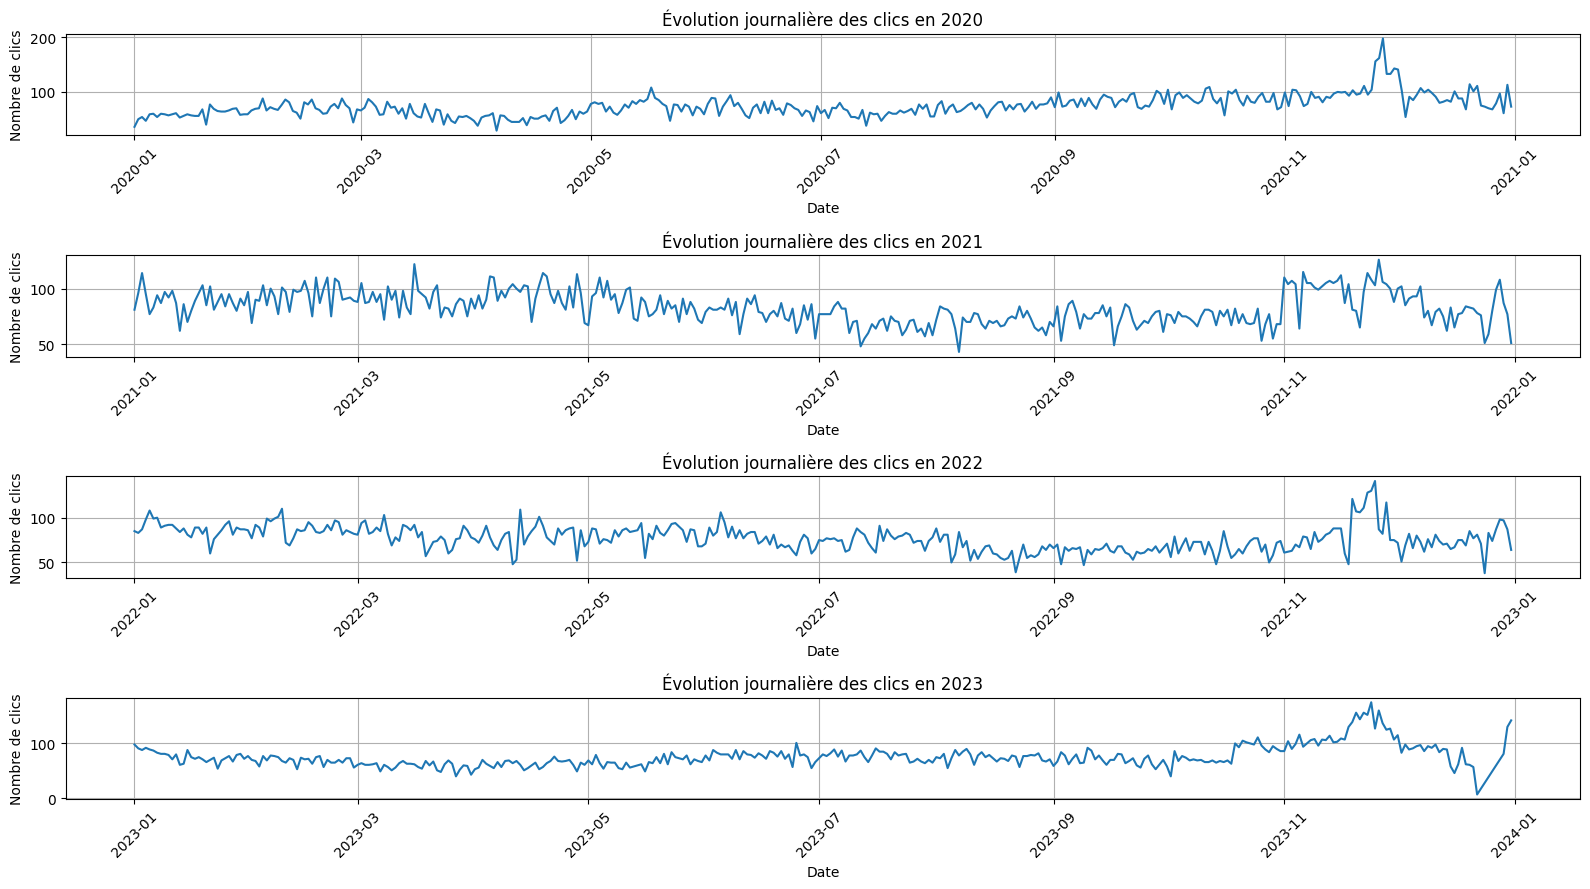

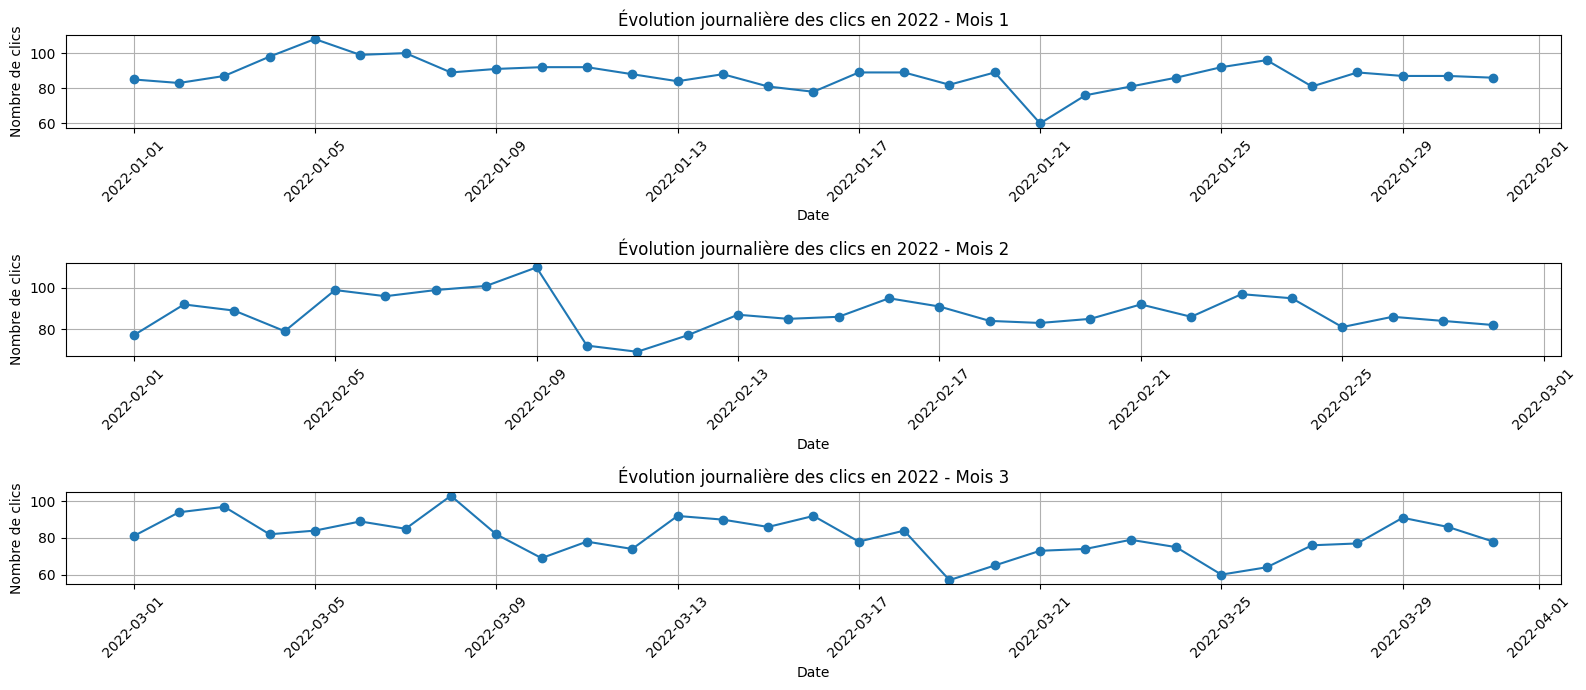

In [112]:
liste_id = df_train['ID'].unique()
i = 0
df_train_id = df_train[df_train['ID']==liste_id[i]]

# Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9)) 

for i, annee in enumerate(annees, 1):
    df_year = df_train_id[df_train_id['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train_id[(df_train_id['date'].dt.year == annee_zoom) & (df_train_id['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Interprétation des graphiques de l'évolution journalières des clics:**

Bien qu’aucune saisonnalité marquée ne soit directement perceptible à l’œil nu dans les visualisations globales, cela n’exclut pas l’existence de motifs saisonniers plus fins. 

La présence d’une tendance forte, de pics extrêmes et l’agrégation des données peuvent masquer des effets saisonniers de faible amplitude mais réguliers. 

L’introduction de variables temporelles explicites (jour de la semaine, mois, semaine de l’année) permet aux modèles d’exploiter ces régularités, même lorsqu’elles ne sont pas immédiatement visibles dans les graphiques.

## 3. Feature Engineering

La création de features est essentielle pour capturer les informations temporelles et les dépendances historiques. 

Les fonctions suivantes sont définies :

**Features temporelles** (fonctions `features_date`) :
- Jour du mois, mois, année, numéro de semaine (norme ISO), jour de l'année, jour de la semaine
- Variables booléennes : weekend (oui/non), premier jour du mois, dernier jour du mois
- Semaine du mois, jours fériés (avec marge de 1 jour avant/après), variable temporelle pour changement de régime publicitaire

**Encodage des variables catégorielles** (fonction `features_cat`) :
- Conversion des colonnes `ad_type` et `currency` en variables dummy (one-hot encoding)

**Lags et différences** (fonction `features_lags`) :
- Lags de 7 à 14 jours pour `clicks`, `impressions`, `cost` pour capter l'autocorrélation
- Différences entre lags pour identifier les variations court terme

**Statistiques temporelles** (fonctions `features_stat_semaine`, `features_stat_mois`) :
- Mean, std, min, max des clics, impressions et coûts agrégés par semaine et par mois

In [113]:
# Tri des données par ID client et date pour faciliter le traitement séquentiel
df_train.sort_values(by=['ID', 'date'], inplace=True)

In [114]:
def semaine_du_mois(valeur_date):
    """Calcul à quelle semaine du mois appartient la date."""
    result = valeur_date.day + valeur_date.replace(day=1).weekday()
    return int(np.ceil(result / 7))

liste_jours_feries = [
        (16, 12), # Jour de la réconciliation
        (25, 12), # fête de Noël
        (1, 1),   # Jour du nouvel an
        (27, 4),  # Jour de la liberté
        (1, 5),   # fête du travail
        (9, 8),   # Jour National de la femme
        (24, 9),  # Journée du patrimoine
        (26, 12),  # Jour de la Bonne Volonté
        (21, 3),  # Jour des droits de l'homme
        (16, 6),  # fête de la jeunesse
    ]

def template_train_set(df, id):
    """Construit le dataframe de telle manière à garantir une ligne par jour (aucun trou temporel), même si le client
    n'avait pas de données certains jours."""
    dates = pd.date_range(start=df['date'].min(), end=df['date'].max())
    df_avec_toutes_les_dates = pd.DataFrame({'date' : dates, 'ID' : id})
    result = pd.merge(df_avec_toutes_les_dates, df, on=['date', 'ID'], how='left')
    return result

def features_date(df):
    """Fonction qui calcule les nouvelles features à partir de la date (pour capter si possible la saisonnalité si elle existe)."""
    ## features temporelles
    df['jour'] = df['date'].dt.day # extraction du jour du mois correspondant à la date du clic
    df['annee'] = df['date'].dt.year # annee conrrespondante à la date du clic
    df['mois'] = df['date'].dt.month # mois correspondant à la date du clic
    df['semaine'] = df['date'].dt.isocalendar().week # numero de la semaine de l'année (selon la norme ISO)
    df['jour_de_annee'] = df['date'].dt.dayofyear # extraction du rang du jour dans l'annee
    df['jour_de_semaine'] = df['date'].dt.dayofweek # extraction du rang du jour de la semaine
    df['trismestre_annee'] = df['date'].dt.quarter # trimestre de l'annee correspondant à la date
    df['weekend'] = df['date'].dt.dayofweek >= 5 # variable booleenne weekend (1 si oui 0 sinon)
    df['premier_du_mois'] = df['date'].dt.is_month_start.astype(int) # premier jour du mois (booleen)
    df['dernier_du_mois'] = df['date'].dt.is_month_end.astype(int)  # dernier jour du mois (booleen)
    df['semaine_du_mois'] = df['date'].apply(semaine_du_mois)  # extraction de la semaine du mois
    df['jours_ferie'] = df['date'].apply(lambda d: any(abs((d - pd.Timestamp(year=d.year, month=m, day=j)).days) <= 1
                  for j, m in liste_jours_feries)) # 1 si le jour est férié ou à la veille et le lendemain d'un jour férié
    df['post_change'] = df['date'] >= '2022-06-01' # Pour capturer un changement le régime (entre le type de publicité)
    return df

def features_cat(df):
    ad_type_dummies = pd.get_dummies(df['ad_type'], dtype=bool)
    currency_dummies = pd.get_dummies(df['currency'], dtype=bool)
    df = pd.concat([df, ad_type_dummies], axis=1)
    df = pd.concat([df, currency_dummies], axis=1)
    df.drop(['ad_type', 'currency'], axis=1, inplace=True)
    return df

def features_lags(df, cols, lags, lags_diff):
    """Calcul des lags et des différences entre lags."""
    df.sort_values(by = ['date'], inplace=True)
    # lags
    for col in cols:
            for shift in lags:
                df[f"lag_{col}_{shift}"] = df[col].shift(shift)
    
    # différences entre lags
    for col in cols:
            for shift in lags_diff:
                df[f"diff_{col}_lag_{shift}"] = df[f"lag_{col}_{lags_diff[0]}"] - df[f"lag_{col}_{shift}"]
    return df

def features_stat_semaine(df):
     """Calcul des features statistiques par semaine : mean, std, min, max."""
     # stat par semaine
     df_semaine = df.groupby('semaine').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_semaine.columns = ['semaine'] + [f"semaine_{col}_{stat}" for col, stat in df_semaine.columns[1:]]
     return df_semaine

def features_stat_mois(df):
     """Calcul des features statistiques par mois : mean, std, min, max."""
     # stat par mois
     df_mois = df.groupby('mois').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_mois.columns = ['mois'] + [f"mois_{col}_{stat}" for col, stat in df_mois.columns[1:]]
     return df_mois

In [115]:
df_train_2 = features_cat(df_train)

## 4. Construction du jeu d'entraînement

Le jeu d'entraînement est construit client par client via la fonction `construction_train_set` :
1. Sélection des données pour le client
2. Création d'une série complète sans jours manquants (template_train_set)
3. Génération des features temporelles
4. Agrégation si plusieurs observations par jour
5. Ajout des statistiques par mois/semaine
6. Calcul des lags et différences
7. Suppression des colonnes non nécessaires (impressions, cost)

L'encodage des IDs clients en entiers et la conversion des colonnes booléennes en type bool garantissent un format correct pour les modèles.

In [116]:
def construction_train_set(df, id):
    """Processus de construction du Train Set."""
    train_id_set = df[df['ID'] == id] # on fait les preprocessing pour chaque ID (chaque client)
    train_template = template_train_set(train_id_set, id) # on applique la fonction template_train_set
    train_feature_date = features_date(train_template) # on applique la fonction features_dates

    # On aggrège le dataframe car plusieurs observation pour une même date
    train_feature_date_agg = train_feature_date.groupby('date').agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'cost' : 'sum',
        'EXPANDED_DYNAMIC_SEARCH_AD': 'max',
        'EXPANDED_TEXT_AD': 'max',
        'RESPONSIVE_SEARCH_AD': 'max',
        'ZAR': 'max',
        'USD': 'max',
        'ID': 'first',
        'jour': 'first',
        'semaine_du_mois': 'first',
        'trismestre_annee': 'first',
        'mois': 'first',
        'weekend': 'first',
        'jour_de_annee': 'first',
        'premier_du_mois': 'first',
        'annee': 'first',
        'semaine': 'first',
        'dernier_du_mois': 'first',
        'jours_ferie' : 'first',
        'jour_de_semaine':'first',
        'post_change':'first'
    }).reset_index()

    # création des colonnes stats
    stat_semaine = features_stat_semaine(train_feature_date)
    stat_mois = features_stat_mois(train_feature_date)
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_mois, on='mois', how='left')
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_semaine, on='semaine', how='left')

    # création des colonnes lags
    lag_cols = ['clicks', 'impressions', 'cost'] # colonnes à lagger
    train = features_lags(train_feature_date_agg, lag_cols, range(7, 15), range(8, 15))
    train.drop(['impressions', 'cost'], axis=1, inplace=True)
    return train

In [117]:
train_set_par_id = []
for id in [df_train_2['ID'].unique()][0]:
    train_set = construction_train_set(df_train_2, id)
    train_set_par_id.append(train_set)

In [118]:
### DATAFRAME D'ENTRAINEMENT
train = pd.concat(train_set_par_id)
encode = LabelEncoder()
train['ID'] = encode.fit_transform(train['ID'])
train = train.sort_values(by=['date', 'ID']).reset_index(drop=True)

bool_cols = ["EXPANDED_DYNAMIC_SEARCH_AD", "EXPANDED_TEXT_AD",
             "RESPONSIVE_SEARCH_AD", "ZAR", "USD"]

# Conversion en bool
for col in bool_cols:
    train[col] = train[col].astype(bool)

## 5. Modélisation et Validation Temporelle

Nous entraînons et évaluons trois algorithmes d'ensemble sur le jeu d'entraînement complété avec validation temporelle :

**Stratégie de validation** (fonction `get_date_based_splits`) :
- Split basé sur les dates (5 folds) pour respecter l'ordre chronologique
- Chaque fold utilise les 7 derniers jours comme ensemble de test
- Prévention du data leakage par séparation temporelle stricte

**Modèles testés** :
1. **LightGBM** : boosting gradient rapide, bon avec données hétérogènes
2. **XGBoost** : boosting régularisé, excellent pour la prédiction et interprétabilité
3. **RandomForest** : ensemble non-boosting, robuste et interprétable

**Métrique** : RMSE (Root Mean Squared Error) sur chaque fold, puis moyenne

**Sortie** : RMSE moyen et graphiques d'importance des features (top 50) pour identifier les variables influentes

In [119]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBRegressor
from math import sqrt

### 1. Préparation des données pour la modélisation 

In [120]:
# On sélectionne toutes les features (X) en excluant la date et la cible (clicks)
X = [c for c in train.columns if c not in ["date", "clicks"]]

# On vérifie le nombre de valeurs manquantes dans clicks
n_missing_clicks = train['clicks'].isna().sum()
print(f"Valeurs manquantes dans 'clicks': {n_missing_clicks}")

# Normalement, il n'en reste pas, parce que ça a déjà été fait dans le nettoyage mais sinon on les supprime 
print(f"Shape des données d'entraînement: {train.shape}")
print(f"Nombre de features: {len(X)}")
print(f"Features utilisées: {X}")  

Valeurs manquantes dans 'clicks': 0
Shape des données d'entraînement: (81008, 90)
Nombre de features: 88
Features utilisées: ['EXPANDED_DYNAMIC_SEARCH_AD', 'EXPANDED_TEXT_AD', 'RESPONSIVE_SEARCH_AD', 'ZAR', 'USD', 'ID', 'jour', 'semaine_du_mois', 'trismestre_annee', 'mois', 'weekend', 'jour_de_annee', 'premier_du_mois', 'annee', 'semaine', 'dernier_du_mois', 'jours_ferie', 'jour_de_semaine', 'post_change', 'mois_clicks_mean', 'mois_clicks_std', 'mois_clicks_min', 'mois_clicks_max', 'mois_impressions_mean', 'mois_impressions_std', 'mois_impressions_min', 'mois_impressions_max', 'mois_cost_mean', 'mois_cost_std', 'mois_cost_min', 'mois_cost_max', 'semaine_clicks_mean', 'semaine_clicks_std', 'semaine_clicks_min', 'semaine_clicks_max', 'semaine_impressions_mean', 'semaine_impressions_std', 'semaine_impressions_min', 'semaine_impressions_max', 'semaine_cost_mean', 'semaine_cost_std', 'semaine_cost_min', 'semaine_cost_max', 'lag_clicks_7', 'lag_clicks_8', 'lag_clicks_9', 'lag_clicks_10', 'la

### 2. Validation Temporelle : Fonction `get_date_based_splits`

La validation temporelle est essentielle pour éviter le **data leakage** dans les séries temporelles. 

Contrairement à une cross-validation classique, on ne peut pas mélanger les données car l'ordre chronologique importe.

**Principe :**
- On divise les données en 5 folds chronologiques
- Pour chaque fold : on entraine sur des données **anciennes**, on teste sur des données **plus récentes**
- On souhaite garantir une séparation stricte : jamais de chevauchement temporel

**Exemple avec 3 folds et 7 jours de test (100 jours total) :**
```
Fold 1 : Train sur jours 1-79  |  Test sur jours 80-86
Fold 2 : Train sur jours 1-72  |  Test sur jours 73-79  
Fold 3 : Train sur jours 1-65  |  Test sur jours 66-72
```

Chaque test set est strictement **après** le train set → simulation d'une vraie prédiction future

In [121]:
def get_date_based_splits(df, n_splits=5, test_days=7):
    """
    Crée n_splits folds temporels pour validation chronologique (sans data leakage).
    Retour : Liste de tuples (train_idx, test_idx) triés chronologiquement.
    """
    
    # On extrait toutes les dates uniques et on les trie
    unique_dates = np.sort(df['date'].unique())
    print(f"Total de jours : {len(unique_dates)} | Plage : {unique_dates[0]} à {unique_dates[-1]}\n")
    
    splits = []
    
    # On crée les folds en partant de la fin des données
    for i in range(n_splits):
        # On calcule la période de test : les test_days derniers jours du fold i
        test_end = unique_dates[-(i * test_days + 1)]
        test_start = unique_dates[-((i + 1) * test_days)]
        
        # On sélectionne toutes les lignes pour cette période de test
        test_dates = unique_dates[(unique_dates >= test_start) & (unique_dates <= test_end)]
        test_idx = df[df['date'].isin(test_dates)].index
        
        # On sélectionne toutes les lignes avant cette période (-> pour l'entraînement)
        # On garantit aucun chevauchement temporel
        train_idx = df[df['date'] < test_start].index
        
        splits.append((train_idx, test_idx))
        print(f"Fold {i+1}: Train {len(train_idx)} obs | Test {len(test_idx)} obs (du {test_start} au {test_end})")
    
    # On inverse pour avoir les folds dans l'ordre chronologique (du plus ancien au plus récent)
    return splits[::-1]


In [122]:
splits = get_date_based_splits(train, n_splits=5, test_days=7)

Total de jours : 1505 | Plage : 2020-01-01T00:00:00.000000000 à 2024-02-13T00:00:00.000000000

Fold 1: Train 80391 obs | Test 617 obs (du 2024-02-07T00:00:00.000000000 au 2024-02-13T00:00:00.000000000)
Fold 2: Train 79728 obs | Test 663 obs (du 2024-01-31T00:00:00.000000000 au 2024-02-06T00:00:00.000000000)
Fold 3: Train 79040 obs | Test 688 obs (du 2024-01-24T00:00:00.000000000 au 2024-01-30T00:00:00.000000000)
Fold 4: Train 78334 obs | Test 706 obs (du 2024-01-17T00:00:00.000000000 au 2024-01-23T00:00:00.000000000)
Fold 5: Train 77581 obs | Test 753 obs (du 2024-01-10T00:00:00.000000000 au 2024-01-16T00:00:00.000000000)


### 3. Tests différents modèles 

### Modèle 1 : LightGBM (Gradient Boosting rapide)

**LightGBM** (Light Gradient Boosting Machine) est un algorithme de **boosting gradient** très performant et rapide.

**Caractéristiques principales :**
- Crée une **séquence d'arbres de décision** qui corrigent progressivement les erreurs précédentes
- Utilise le **gradient boosting** : chaque nouvel arbre prédit les résidus (erreurs) du précédent
- **Très efficace** avec les données volumineuses et hétérogènes
- **Interprétable** : on peut extraire l'importance de chaque feature

**Hyperparamètres choisis :**
- `n_estimators=1000` : 1000 arbres (plus = plus complexe mais risque de surapprentissage)
- `learning_rate=0.05` : pas d'apprentissage faible (régularisation = moins de surapprentissage)
- `num_leaves=64` : nombre de feuilles max par arbre (plus = plus complexe)
- `categorical_feature=["ID"]` : traite l'ID comme catégorie, pas comme nombre

On va entraîner LightGBM sur **5 folds** avec validation temporelle et calculer le **RMSE moyen**.

In [123]:
scores = []
for fold, (train_idx, test_idx) in enumerate(splits, 1):
    # On sépare X/y
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    # Modèle (hyperparamètres conservés)
    model_lgb = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=64, random_state=42, n_jobs=-1)

    # Entraînement et évaluation sur le fold courant
    model_lgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse", categorical_feature=["ID"])
    preds = model_lgb.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    scores.append(rmse)

    print(f"Fold {fold}: RMSE = {rmse:.2f}")

# Résumé
print(f"RMSE moyen: {np.mean(scores):.2f} | éc.t.: {np.std(scores):.2f} | par fold: {[f'{s:.2f}' for s in scores]}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16400
[LightGBM] [Info] Number of data points in the train set: 77581, number of used features: 88
[LightGBM] [Info] Start training from score 25.299970
Fold 1: RMSE = 52.09
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16406
[LightGBM] [Info] Number of data points in the train set: 78334, number of used features: 88
[LightGBM] [Info] Start training from score 25.456417
Fold 2: RMSE = 40.90
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004209 seconds.
You can set `force_row_wise=true` to r


Top 10 features (LightGBM):
    importance             feature
34        3331  semaine_clicks_max
5         2997                  ID
43        2266        lag_clicks_7
68        2092   diff_clicks_lag_9
6         1803                jour
73        1786  diff_clicks_lag_14
69        1541  diff_clicks_lag_10
11        1469       jour_de_annee
71        1440  diff_clicks_lag_12
70        1423  diff_clicks_lag_11


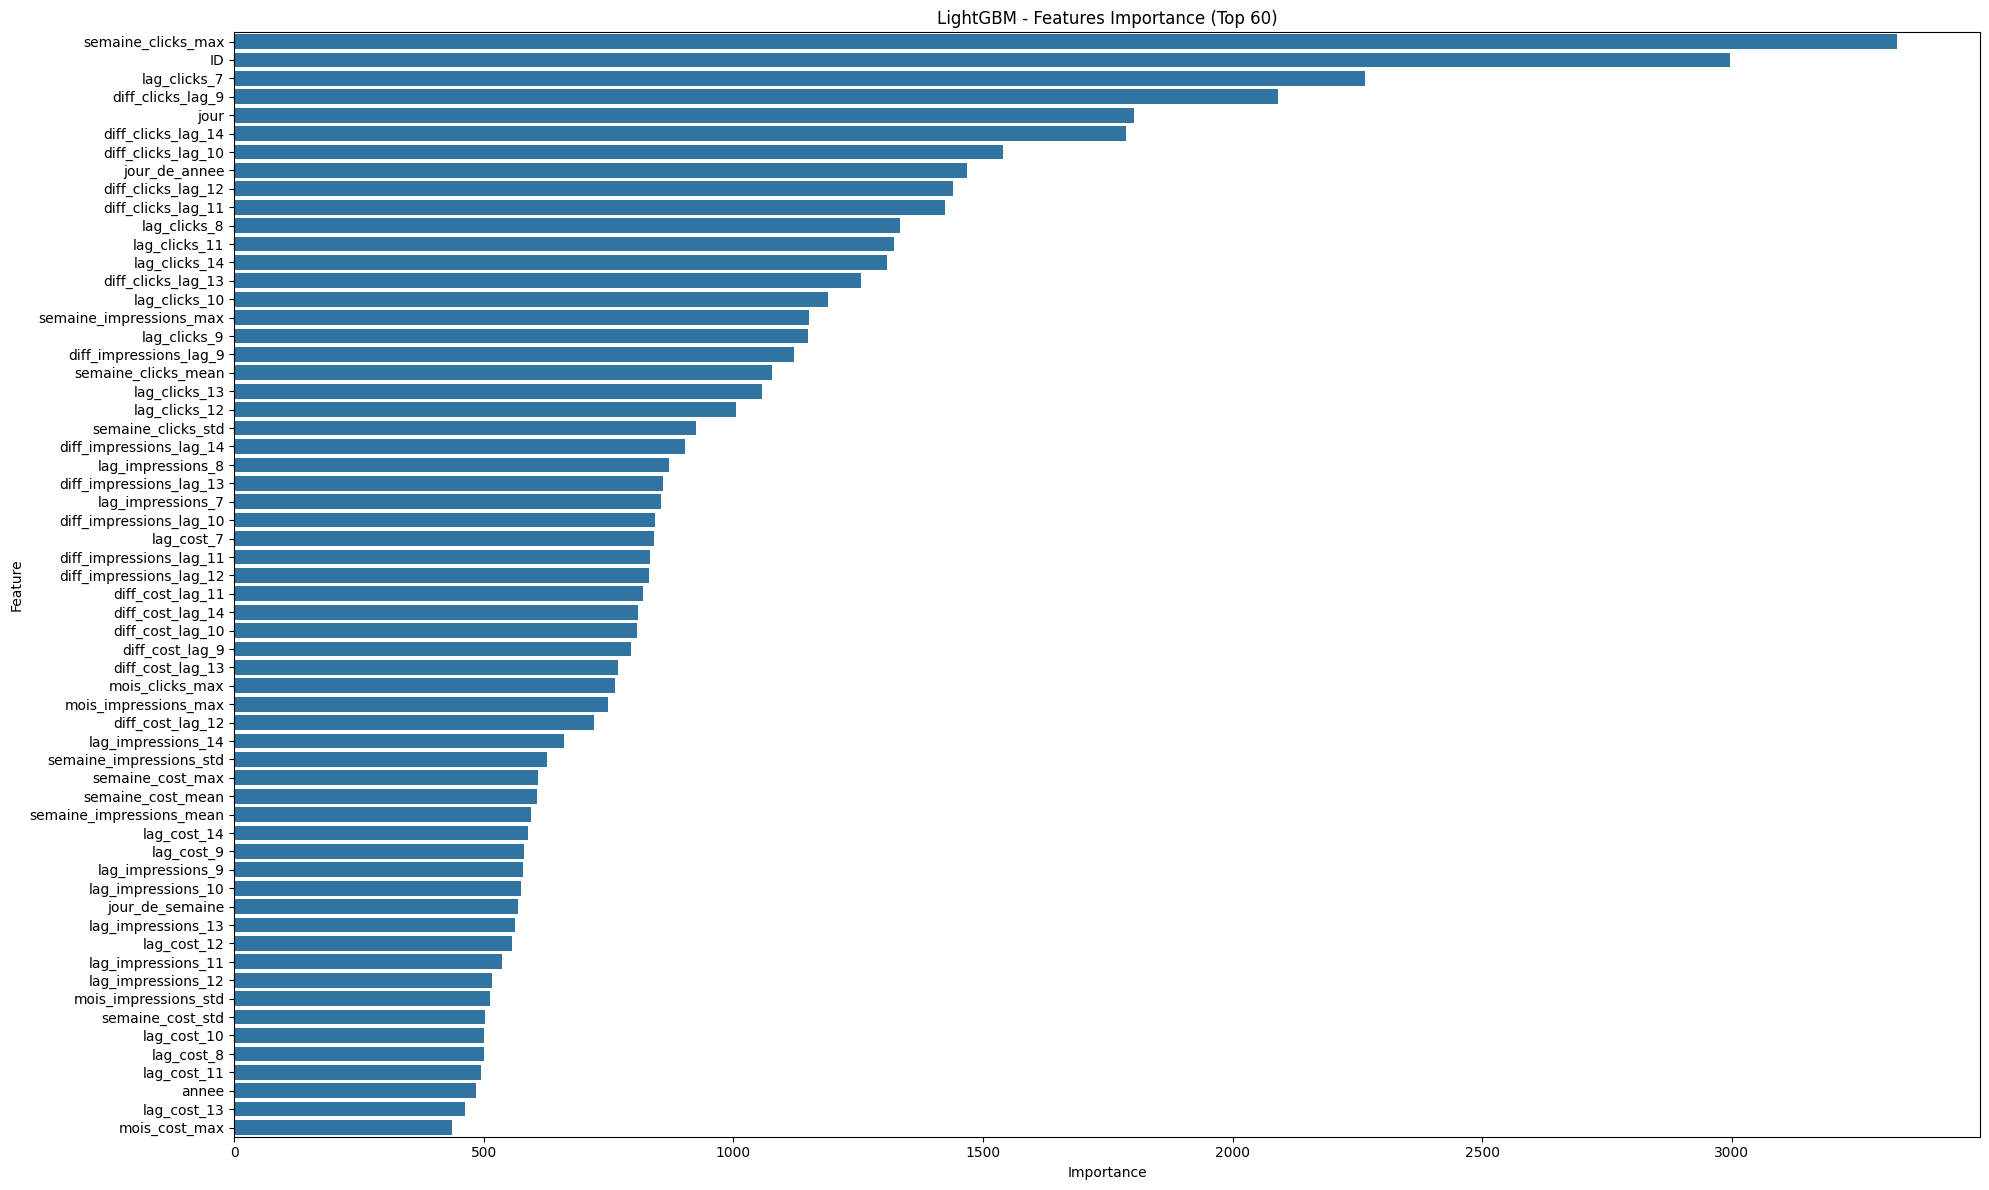

In [124]:
# Analyse de l'importance des features pour LightGBM
feature_importance_lgb = pd.DataFrame(model_lgb.feature_importances_, columns=['importance'])
feature_importance_lgb['feature'] = X
feature_importance_lgb = feature_importance_lgb.sort_values(by=['importance'], ascending=False)

print(f"\nTop 10 features (LightGBM):")
print(feature_importance_lgb.head(10))

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance_lgb.head(60))
plt.title('LightGBM - Features Importance (Top 60)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Modèle 2 : Random Forest (Ensemble non-boosting)

**Random Forest** est un ensemble d'arbres de décision construits par bagging (bootstrap aggregation). 

Il est robuste face au bruit et efficace sans trop de tuning.

**Caractéristiques principales :**
- Réduit la variance en moyennant plusieurs arbres indépendants
- Robuste aux outliers et aux features non pertinentes
- Interprétable via les importances de features (gain ou réduction d'impureté)

**Hyperparamètres choisis dans ce notebook :**
- `n_estimators=200` : nombre d'arbres
- `max_depth=10` : profondeur maximale pour limiter l'overfitting
- `min_samples_split=5`, `min_samples_leaf=2` : régularisation par taille minimale des noeuds

Nous entraînons le Random Forest sur les mêmes folds temporels (5 folds) et calculons le RMSE par fold pour comparer avec LightGBM.

In [125]:
print("\n" + "="*60)
print("MODÈLE 2 : RANDOM FOREST (Ensemble non-boosting)")
print("="*60)

# Entraînement et validation temporelle pour Random Forest
scores_rf = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit( X_train, y_train)

    preds = rf.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))



MODÈLE 2 : RANDOM FOREST (Ensemble non-boosting)
Fold 1 rmse = 63.14
Fold 2 rmse = 20.48
Fold 3 rmse = 20.77
Fold 4 rmse = 59.78
Fold 5 rmse = 21.14
RSME moyen: 38.314382336206016



Top 10 features (Random Forest):
    importance                  feature
43    0.666851             lag_clicks_7
44    0.139949             lag_clicks_8
32    0.051681       semaine_clicks_std
34    0.024456       semaine_clicks_max
45    0.022354             lag_clicks_9
31    0.012439      semaine_clicks_mean
36    0.011511  semaine_impressions_std
47    0.004434            lag_clicks_11
38    0.003387  semaine_impressions_max
4     0.003207                      USD


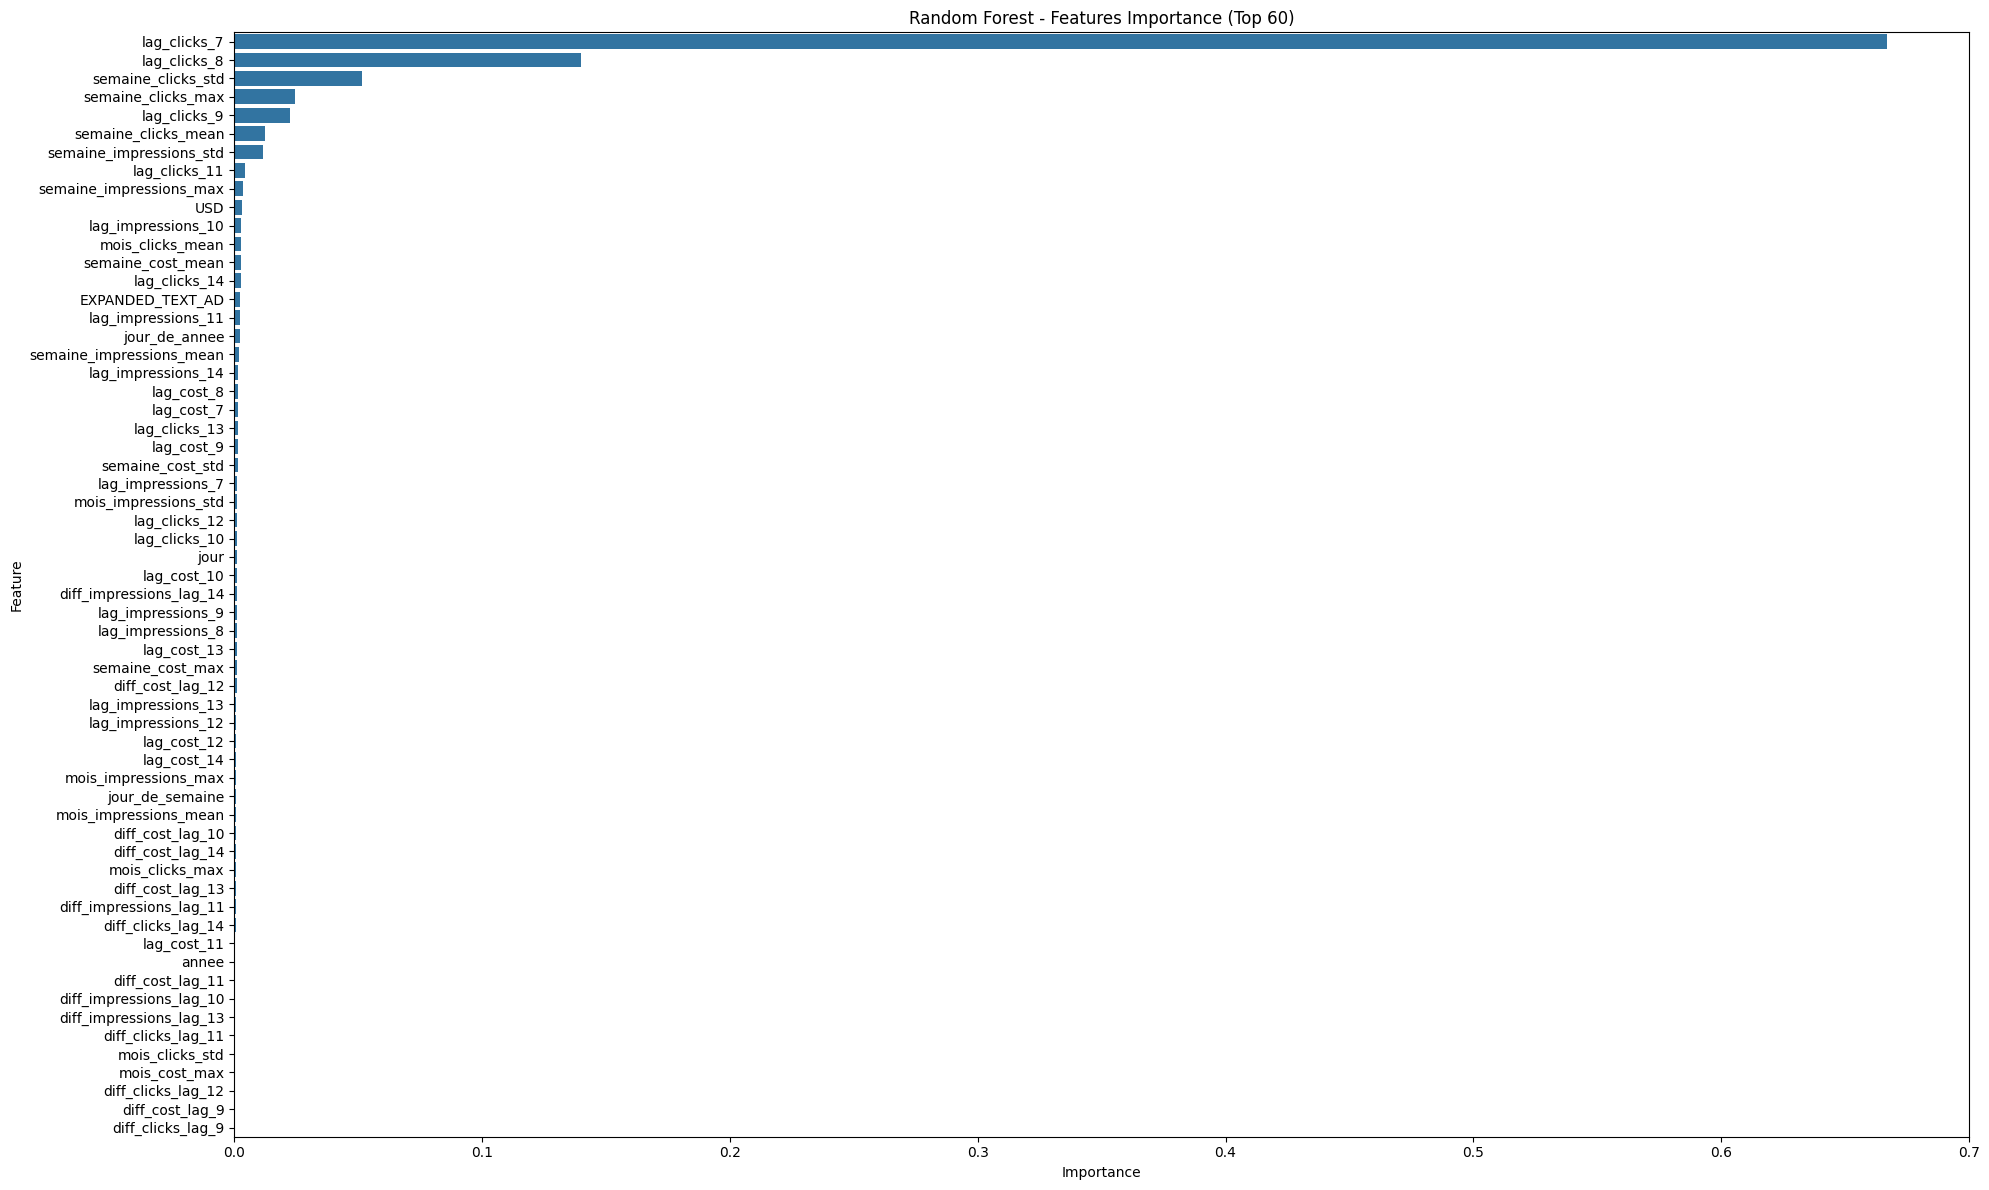

In [126]:
# Analyse de l'importance des features pour Random Forest
feature_importance_rf = pd.DataFrame(rf.feature_importances_, columns=['importance'])
feature_importance_rf['feature'] = X
feature_importance_rf = feature_importance_rf.sort_values(by=['importance'], ascending=False)

print(f"\nTop 10 features (Random Forest):")
print(feature_importance_rf.head(10))

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance_rf.head(60))
plt.title('Random Forest - Features Importance (Top 60)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Modèle 3 : XGBoost (Gradient Boosting régularisé)

**XGBoost** est un algorithme de gradient boosting efficace et régularisé. Il construit des arbres séquentiels où chaque nouvel arbre corrige les erreurs résiduelles des précédents.

**Caractéristiques principales :**
- Boosting de gradients : très performant pour des tâches de prédiction supervisée
- Options de régularisation (L1/L2), subsampling et contrôle des profondeurs pour limiter l'overfitting
- Interprétable via l'importance des features (gain, cover, frequency)

**Hyperparamètres choisis dans ce notebook :**
- `n_estimators=1000`, `learning_rate=0.05` : compromis précision / vitesse
- `max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8` : réglages pour la robustesse

XGBoost sera entraîné sur les mêmes folds temporels et évalué en RMSE pour permettre une comparaison directe avec LightGBM et Random Forest.

In [127]:
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_xgb.fit( X_train, y_train)

    preds = model_xgb.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))

Fold 1 rmse = 63.88
Fold 2 rmse = 15.58
Fold 3 rmse = 23.31
Fold 4 rmse = 58.28
Fold 5 rmse = 19.92
RSME moyen: 36.192661224448536


Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

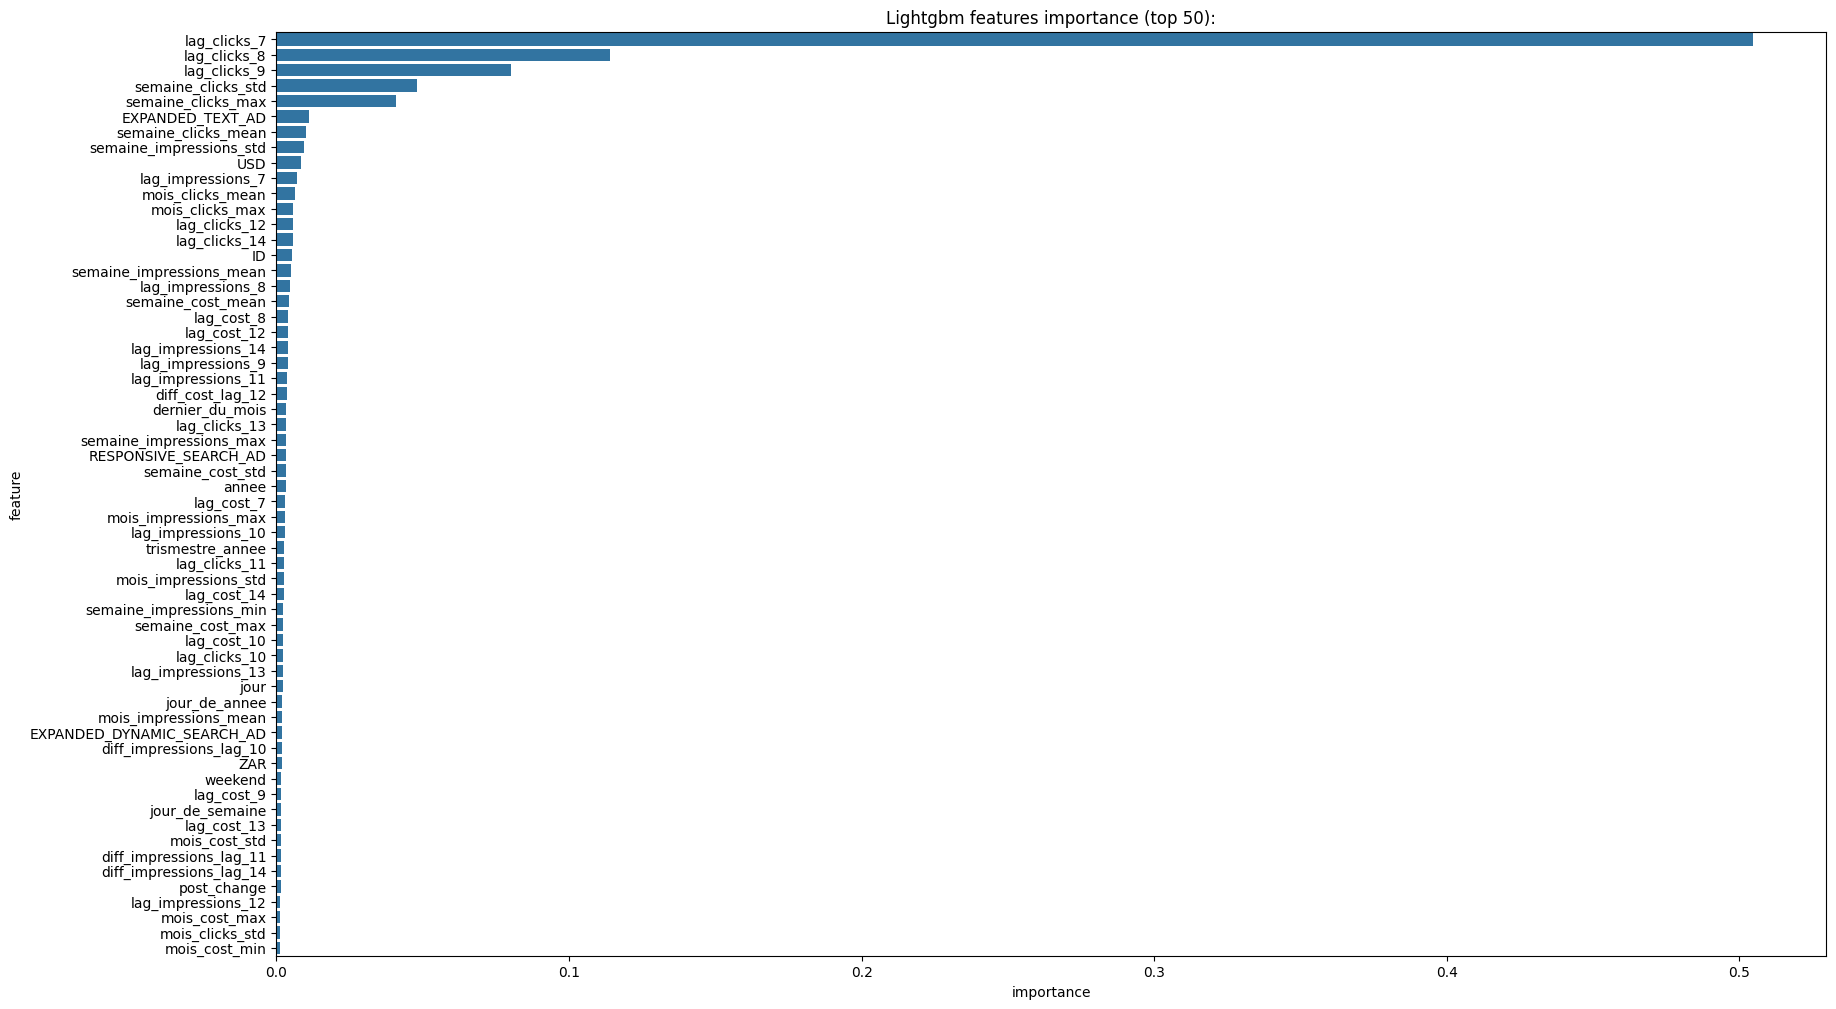

In [128]:
feature_importance = pd.DataFrame(model_xgb.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [129]:
# num_vars = [ 'impressions', 'cost', 'conversions', 'impression_share', 'headline1_len', 'headline2_len', 'ad_description_len']
# cat_vars = ['ad_type', 'currency']
# results_num = []
# results_cat = []

# for var in num_vars:
#     df_tmp = df_train[[var, 'clicks']].dropna()
    
#     pearson_corr, pearson_p = pearsonr(df_tmp[var], df_tmp['clicks'])
#     spearman_corr, spearman_p = spearmanr(df_tmp[var], df_tmp['clicks'])
    
#     results_num.append({
#         'variable': var,
#         'pearson_corr': pearson_corr,
#         'pearson_pvalue': pearson_p,
#         'spearman_corr': spearman_corr,
#         'spearman_pvalue': spearman_p
#     })

# results_num_df = pd.DataFrame(results_num)
# display(results_num_df.sort_values('pearson_pvalue'))



# for var in cat_vars:
#     groups = [
#         df_train[df_train[var] == cat]['clicks'].dropna()
#         for cat in df_train[var].unique()
#     ]
    
#     stat, p = kruskal(*groups)
    
#     results_cat.append({
#         'variable': var,
#         'test': 'Kruskal-Wallis',
#         'p_value': p
#     })

# results_cat_df = pd.DataFrame(results_cat)
# results_cat_df

## 6. Conclusions et Prochaines Étapes

### Résultats obtenus
- Trois modèles entraînés et évalués avec validation temporelle rigoureuse
- Scores RMSE comparables entre les modèles
- Identification des features les plus impactantes (lags, statistiques temporelles, variables temporelles)

### Interprétabilité
Les graphiques d'importance de features montrent que :
- Les **lags** (historique récent) sont très influents, confirmant l'autocorrélation
- Les **statistiques par semaine/mois** capturent les patterns saisonniers
- Les **variables temporelles** (jour de semaine, jours fériés) ajoutent du contexte utile
- Les **types de publicité** et **devises** jouent un rôle dans la prédiction

### Piste d'amélioration future
- Tuning des hyperparamètres pour chaque modèle
- Ensemble voting des trois modèles pour robustesse
- Analyse des résidus pour détecter les patterns non capturés
- Modèles spécialisés par segment de clients
- Intégration de données externes (météo, événements, tendances saisonnières officielles)